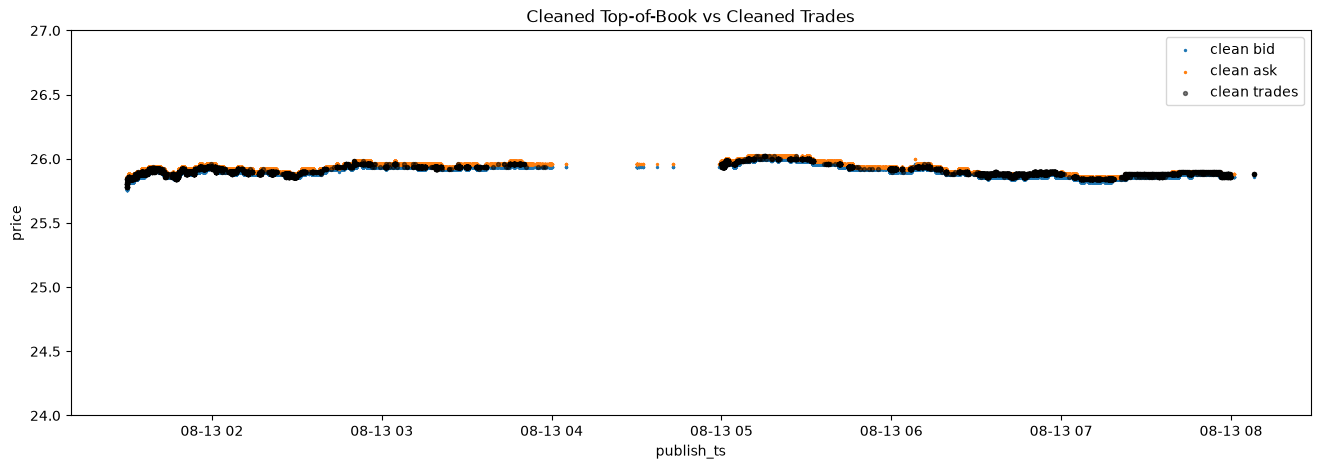

In [12]:
import polars as pl
import matplotlib.pyplot as plt

top = (
    pl.read_parquet("../parquets/A_hkex_2800_top_of_book.parquet")
    .unique()
    .sort("seq_id")
)

trades = (
    pl.read_parquet("../parquets/A_hkex_2800_trades.parquet")
    .unique()
    .with_columns(trade_id_num=pl.col("trade_id").cast(pl.Int64, strict=False))
    .sort(["publish_ts", "ingress_ts", "trade_id_num"])
)

top = top.with_columns(
    missing_bid=pl.col("bid_price").is_null() | pl.col("bid_qty").is_null(),
    missing_ask=pl.col("ask_price").is_null() | pl.col("ask_qty").is_null(),
    spread=pl.col("ask_price") - pl.col("bid_price"),
).with_columns(
    quote_state=
        pl.when(pl.col("missing_bid") & pl.col("missing_ask")).then(pl.lit("no_bbo"))
        .when(pl.col("missing_bid")).then(pl.lit("ask_only"))
        .when(pl.col("missing_ask")).then(pl.lit("bid_only"))
        .otherwise(pl.lit("two_sided")),
    crossed_book=pl.col("bid_price") > pl.col("ask_price"),
    locked_book=pl.col("bid_price") == pl.col("ask_price"),
)

top = top.with_columns(mid=(pl.col("bid_price") + pl.col("ask_price")) / 2)
top = top.with_columns(spread_pct=pl.col("spread") / pl.col("mid") * 100)
top = top.with_columns(spread_outlier=pl.col("spread_pct") > pl.col("spread_pct").quantile(0.99))

top_for_join = top.select(
    pl.col("publish_ts").alias("top_publish_ts"),
    "seq_id",
    "bid_price",
    "bid_qty",
    "ask_price",
    "ask_qty",
    "quote_state",
    "crossed_book",
    "locked_book",
    "spread_outlier",
).sort("top_publish_ts")

trade_top = trades.join_asof(
    top_for_join,
    left_on="publish_ts",
    right_on="top_publish_ts",
    strategy="backward",
)

trade_top = trade_top.with_columns(
    quote_age_us=(pl.col("publish_ts") - pl.col("top_publish_ts")).dt.total_microseconds(),
    trade_below_bid=pl.col("price") < pl.col("bid_price"),
    trade_above_ask=pl.col("price") > pl.col("ask_price"),
    trade_inside_bbo=(pl.col("price") >= pl.col("bid_price")) & (pl.col("price") <= pl.col("ask_price")),
)

trade_top = trade_top.with_columns(
    matched_abnormal_bbo=(
        (pl.col("quote_state") != "two_sided")
        | pl.col("crossed_book")
        | pl.col("locked_book")
        | pl.col("spread_outlier")
    ),
    trade_outside_bbo=pl.col("trade_below_bid") | pl.col("trade_above_ask"),
).with_columns(
    cross_file_anomaly=pl.col("matched_abnormal_bbo") | pl.col("trade_outside_bbo")
)

top_clean = top.filter(
    (pl.col("quote_state") == "two_sided")
    & (~pl.col("crossed_book"))
    & (~pl.col("locked_book"))
    & (~pl.col("spread_outlier"))
)

trade_clean = trade_top.filter(~pl.col("cross_file_anomaly"))

plt.figure(figsize=(16, 5))
plt.scatter(top_clean["publish_ts"], top_clean["bid_price"], s=2, label="clean bid")
plt.scatter(top_clean["publish_ts"], top_clean["ask_price"], s=2, label="clean ask")
plt.scatter(trade_clean["publish_ts"], trade_clean["price"], s=8, color="black", alpha=0.5, label="clean trades")
plt.ylim(24, 27)
plt.title("Cleaned Top-of-Book vs Cleaned Trades")
plt.xlabel("publish_ts")
plt.ylabel("price")
plt.legend()
plt.show()